<a href="https://colab.research.google.com/github/yaRiick/ecommerce-statistical-analysis/blob/main/Ecommerce_Sales_Behavior_SQL_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 E-commerce Data Analysis: A/B Testing & Traffic Performance
**Author:** Yaroslav Matvienko | **Role:** Data Analyst

## 🎯 Project Objective
The primary goal of this project is to analyze user purchasing behavior and evaluate the effectiveness of marketing acquisition channels for an e-commerce platform. By applying statistical hypothesis testing (A/B testing, Kruskal-Wallis, Chi-Square), this analysis aims to uncover actionable insights regarding user registration value, Average Order Value (AOV), and traffic quality to optimize marketing spend.

## 🛠 Tools & Stack
* **Data Extraction:** SQL (Google BigQuery) with complex JOINs to preserve guest sessions.
* **Data Manipulation:** Python (Pandas, NumPy).
* **Statistical Analysis:** `scipy.stats` (Mann-Whitney U, Welch's T-test, Kruskal-Wallis H-test, Chi-Square, D'Agostino-Pearson).
* **Visualization:** Matplotlib, Seaborn.

## 💡 Executive Summary (Key Business Insights)
1. **The "Guest" Paradox (Registration vs. Revenue):** Contrary to common marketing assumptions, unregistered (guest) users not only generate the vast majority of total revenue but also have a **statistically significant higher Average Order Value (AOV)** ($953 vs. $891, p < 0.05). *Recommendation: Avoid forced registration (hard gates) at checkout, especially for high-ticket items.*
2. **Traffic Quality & Purchasing Power:** While `Organic Search` and `Paid Search` drive over 60% of all successful sessions, a Kruskal-Wallis test (p < 0.05) confirmed that purchasing power differs significantly across channels. Not all traffic is equal; specific channels bring "richer" customers per session.
3. **Geographic SEO Variations:** A Chi-Square test confirmed a

In [12]:
# Import libraries
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
from scipy import stats

# 1. Authenticate in Google Colab
auth.authenticate_user()

# 2. Initialize BigQuery client
project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)

# 3. Extract data via SQL (LEFT JOINs preserve non-registered users' data)
sql_query = """
SELECT
    date,
    s.ga_session_id,
    sp.device,
    sp.mobile_model_name,
    sp.continent,
    sp.country,
    sp.browser,
    sp.operating_system,
    sp.`language`,
    sp.medium,
    sp.channel,
    a.id AS user_id,
    a.is_verified,
    a.is_unsubscribed,
    p.category,
    p.name AS product_name,
    p.price,
    p.short_description
FROM `data-analytics-mate.DA.session_params` sp
JOIN `data-analytics-mate.DA.session` s
    ON s.ga_session_id = sp.ga_session_id
JOIN `data-analytics-mate.DA.order` o
    ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
    ON acs.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` p
    ON p.item_id = o.item_id
LEFT JOIN `data-analytics-mate.DA.account` a
    ON acs.account_id = a.id
"""

# 4. Load results into DataFrame
df = client.query(sql_query).to_dataframe()

# Verify data extraction
df.head()

,date,ga_session_id,device,mobile_model_name,continent,country,browser,operating_system,language,medium,channel,user_id,is_verified,is_unsubscribed,category,product_name,price,short_description
0,2020-12-24,5726438444,desktop,Chrome,(not set),(not set),Chrome,Web,None,referral,Paid Search,<NA>,<NA>,<NA>,Cabinets & cupboards,LIXHULT,356.0,"Wall-mounted cabinet combination, 50x25x50 cm"
1,2020-12-13,5614986004,desktop,<Other>,(not set),(not set),<Other>,Web,en-ca,organic,Organic Search,<NA>,<NA>,<NA>,Tables & desks,BEKANT,1325.0,"Desk, 140x60 cm"
2,2020-11-05,8542454082,desktop,Safari,(not set),(not set),Chrome,Web,en-us,(data deleted),Undefined,<NA>,<NA>,<NA>,Chairs,ANTILOP,20.0,Cover
3,2020-12-16,1717992506,mobile,iPhone,(not set),(not set),Safari,Web,en-us,(data deleted),Undefined,<NA>,<NA>,<NA>,Beds,SUNDVIK,849.0,"Ext bed frame with slatted bed base, 80x200 cm"
4,2021-01-16,8416141289,desktop,Safari,(not set),(not set),Chrome,Web,en-gb,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,ALGOT,130.0,"Wall upright/drying rack, 66x41x197 cm"


In [13]:
# --- 1. General Info ---
# df.info() prints automatically, so print() is omitted
df.info()

# --- 2. Missing Values ---
# Filter to show only columns that actually contain nulls
missing = df.isna().sum()
print("\nMissing values:\n", missing[missing > 0])

# --- 3. Duplicates ---
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               33538 non-null  dbdate 
 1   ga_session_id      33538 non-null  Int64  
 2   device             33538 non-null  object 
 3   mobile_model_name  33538 non-null  object 
 4   continent          33538 non-null  object 
 5   country            33538 non-null  object 
 6   browser            33538 non-null  object 
 7   operating_system   33538 non-null  object 
 8   language           22531 non-null  object 
 9   medium             33538 non-null  object 
 10  channel            33538 non-null  object 
 11  user_id            2781 non-null   Int64  
 12  is_verified        2781 non-null   Int64  
 13  is_unsubscribed    2781 non-null   Int64  
 14  category           33538 non-null  object 
 15  product_name       33538 non-null  object 
 16  price              335

In [14]:
# --- 1. Columns & Data Types ---
print(f"Total columns: {len(df.columns)}")

# Separate and display columns by data type
print("\nNumerical columns:", df.select_dtypes(include=['number']).columns.tolist())
print("Categorical columns:", df.select_dtypes(exclude=['number']).columns.tolist())
print("dbdate columns:", df.select_dtypes(include=['dbdate']).columns.tolist())

# --- 2. High-Level Metrics ---
# Calculate total unique sessions
session_cnt = df['ga_session_id'].nunique()
print(f"\nTotal unique sessions: {session_cnt}")

# Calculate the time span of the dataset (using pandas native methods)
date_range = df['date'].max() - df['date'].min()
print(f"Dataset time span: {date_range}")

Total columns: 18

Numerical columns: ['ga_session_id', 'user_id', 'is_verified', 'is_unsubscribed', 'price']
Categorical columns: ['date', 'device', 'mobile_model_name', 'continent', 'country', 'browser', 'operating_system', 'language', 'medium', 'channel', 'category', 'product_name', 'short_description']
dbdate columns: ['date']

Total unique sessions: 33538
Dataset time span: 87 days, 0:00:00


In [15]:
import numpy as np # Required for vectorized operations

# --- 1. Language Standardization ---
# Check unique languages before standardization
print("Original languages:", df['language'].unique())

def unify_language(lang):
    """Standardizes language codes by grouping all 'en' variations."""
    if pd.isna(lang):
        return lang

    # Check if 'en' is part of the language string (e.g., 'en-US', 'en-GB')
    if 'en' in str(lang).lower():
        return "en"
    return lang

# Apply standardizer function
df['united_language'] = df['language'].apply(unify_language)


# --- 2. Registration Status Categorization ---
# Use np.where for faster, vectorized evaluation instead of .apply()
# If user_id is NaN, the user is 'not_registered', otherwise 'is_registered'
df['is_registered'] = np.where(df['user_id'].isna(), 'not_registered', 'is_registered')

# Verify the new columns
df[['language', 'united_language', 'user_id', 'is_registered']].head()

Original languages: [None 'en-ca' 'en-us' 'en-gb' 'ko' 'es-es' 'de' 'en' 'zh' 'fr']


,language,united_language,user_id,is_registered
0,None,None,<NA>,not_registered
1,en-ca,en,<NA>,not_registered
2,en-us,en,<NA>,not_registered
3,en-us,en,<NA>,not_registered
4,en-gb,en,<NA>,not_registered


In [16]:
# ==========================================
# Phase 3: In-Depth Exploratory Data Analysis
# ==========================================

# --- 1. Geographical & Revenue Analysis ---
print("--- Geographical Analysis ---")

top5_country_profit = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5).reset_index()
print("\nTop 5 Countries by Profit:\n", top5_country_profit)

# Top 5 countries per continent by profit
profit_grouped = df.groupby(['continent', 'country'])['price'].sum()
top5_per_continent = profit_grouped.groupby(level='continent', group_keys=False).nlargest(5).reset_index()
top5_per_continent = top5_per_continent.rename(columns={'price': 'total_profit'})
print("\nTop 5 Countries per Continent by Profit:\n", top5_per_continent)

continent_profit = df.groupby('continent')['price'].sum().sort_values(ascending=False).reset_index()
print("\nTotal Profit by Continent:\n", continent_profit)

top5_country_orders = df.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(5).reset_index()
print("\nTop 5 Countries by Order Count:\n", top5_country_orders)


# --- 2. Product & Category Analysis ---
print("\n\n--- Product Analysis ---")

category_profit = df.groupby('category')['price'].sum().sort_values(ascending=False).reset_index()
print("\nProfit by Category:\n", category_profit)

top10_product_profit = df.groupby('product_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()
print("\nTop 10 Products by Profit:\n", top10_product_profit)

# Converted to DataFrame for cleaner formatting
top10_product_orders_cnt = df['product_name'].value_counts().head(10).reset_index()
print("\nTop 10 Products by Order Count:\n", top10_product_orders_cnt)


# --- 3. User Behavior & Registration Metrics ---
print("\n\n--- User Behavior ---")

# Calculate base registration metric (safely dividing by total rows)
registered_pct = (df['user_id'].count() / len(df)) * 100
print(f"\nOverall Registered Users: {registered_pct:.2f}%")

# Filter only registered users to calculate internal metrics
registered_users = df.dropna(subset=['user_id'])
is_verified_pct = registered_users['is_verified'].mean() * 100
unsubscribed_pct = registered_users['is_unsubscribed'].mean() * 100

print(f"Verified Users (among registered): {is_verified_pct:.2f}%")
print(f"Unsubscribed Users (among registered): {unsubscribed_pct:.2f}%")

# Profit share by registration status (Note: spelling fixed to 'is_registered')
profit_by_reg_status = (df.groupby('is_registered')['price'].sum() / df['price'].sum() * 100).sort_values(ascending=False).reset_index()
print("\nProfit Share by Registration Status (%):\n", profit_by_reg_status)

count_reg_by_country = df.groupby('country')['user_id'].count().sort_values(ascending=False).head(10).reset_index()
print("\nTop 10 Countries by Registered Users Count:\n", count_reg_by_country)


# --- 4. Technical Demographics ---
print("\n\n--- Technical Demographics ---")

# Multiplied by 100 and rounded for standard percentage format
print("\nTop Browsers (%):\n", (df['browser'].value_counts(normalize=True) * 100).round(1).head())
print("\nTop Operating Systems (%):\n", (df['operating_system'].value_counts(normalize=True) * 100).round(1).head())
print("\nDevice Types (%):\n", (df['device'].value_counts(normalize=True) * 100).round(1))
print("\nTop Languages (%):\n", (df['united_language'].value_counts(normalize=True) * 100).round(1).head())

--- Geographical Analysis ---

Top 5 Countries by Profit:
           country       price
0   United States  13943553.9
1           India   2809762.0
2          Canada   2437921.0
3  United Kingdom    938317.9
4          France    710692.8

Top 5 Countries per Continent by Profit:
     continent         country  total_profit
0   (not set)       (not set)       74067.4
1      Africa           Egypt       73393.0
2      Africa         Morocco       62148.0
3      Africa    South Africa       58277.1
4      Africa       (not set)       38922.0
5      Africa           Kenya       31590.0
6    Americas   United States    13943553.9
7    Americas          Canada     2437921.0
8    Americas          Brazil      339001.8
9    Americas          Mexico      272896.4
10   Americas            Peru      161221.5
11       Asia           India     2809762.0
12       Asia           China      588329.6
13       Asia          Taiwan      552710.3
14       Asia       Singapore      456447.2
15       Asia 

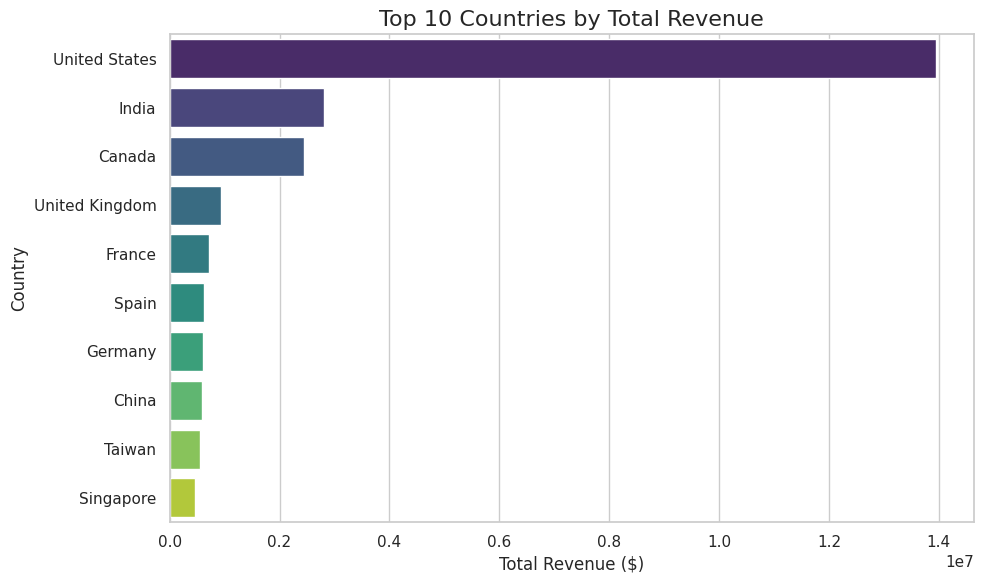

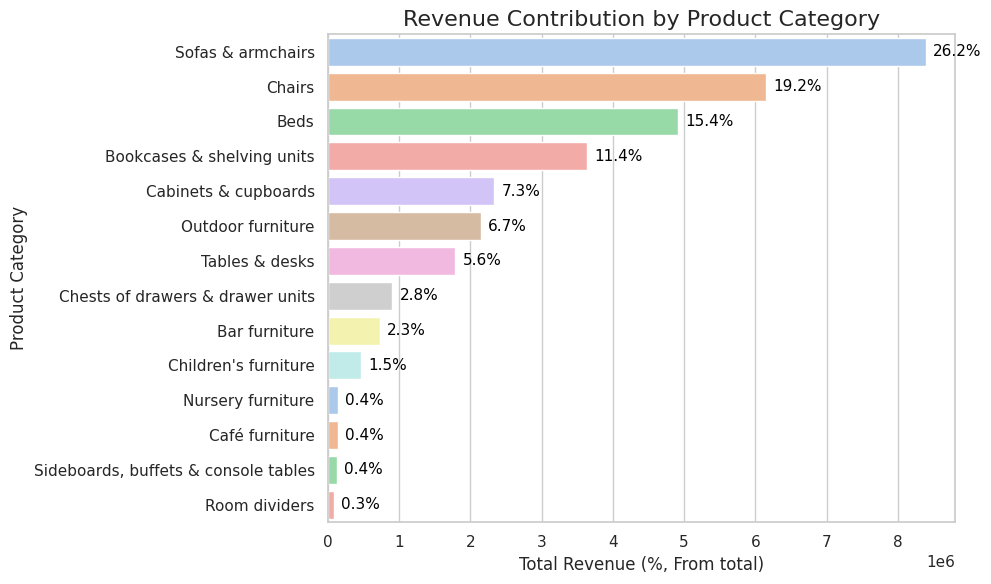

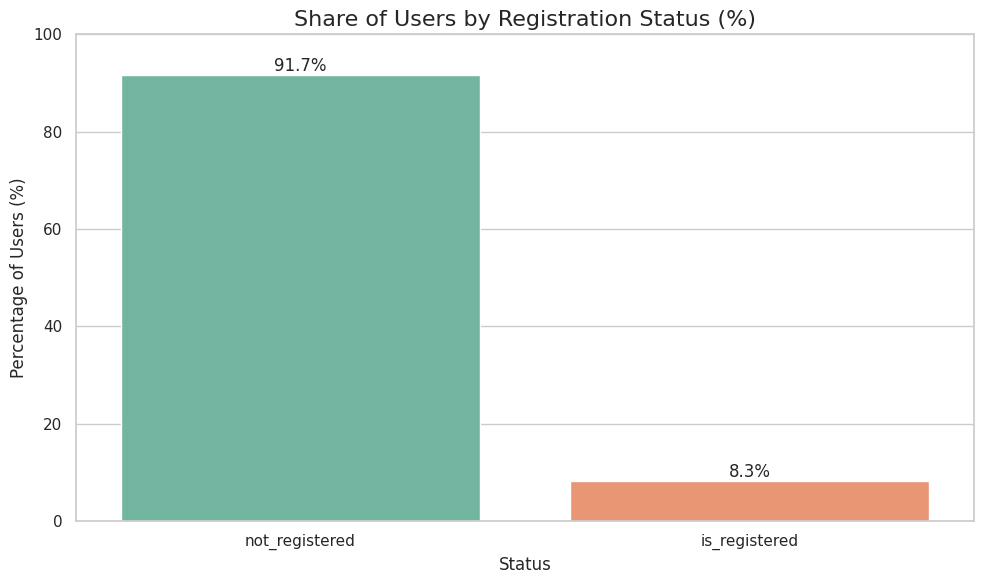

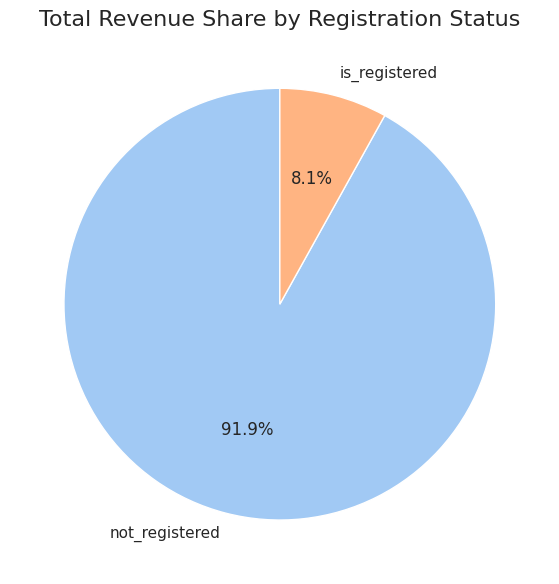

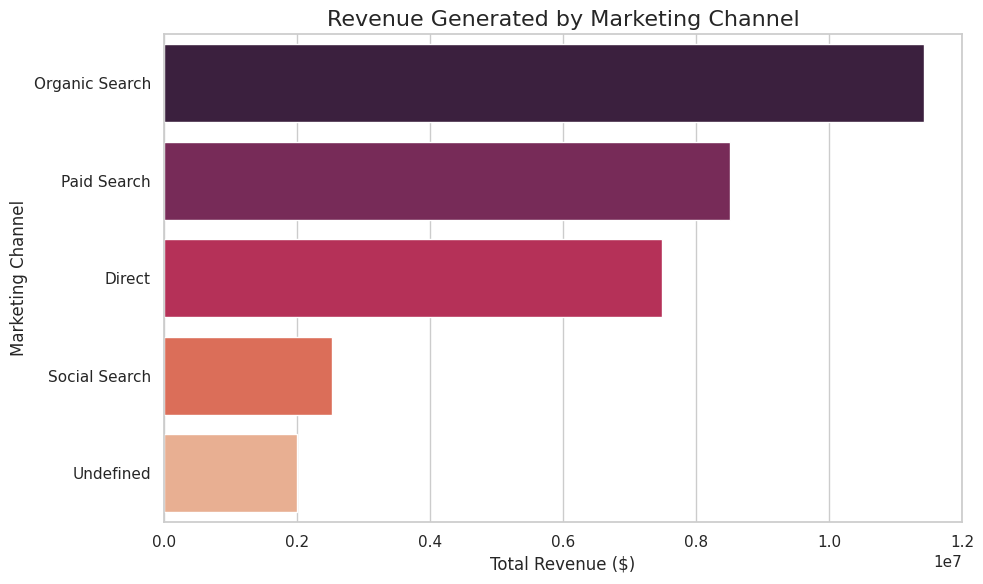

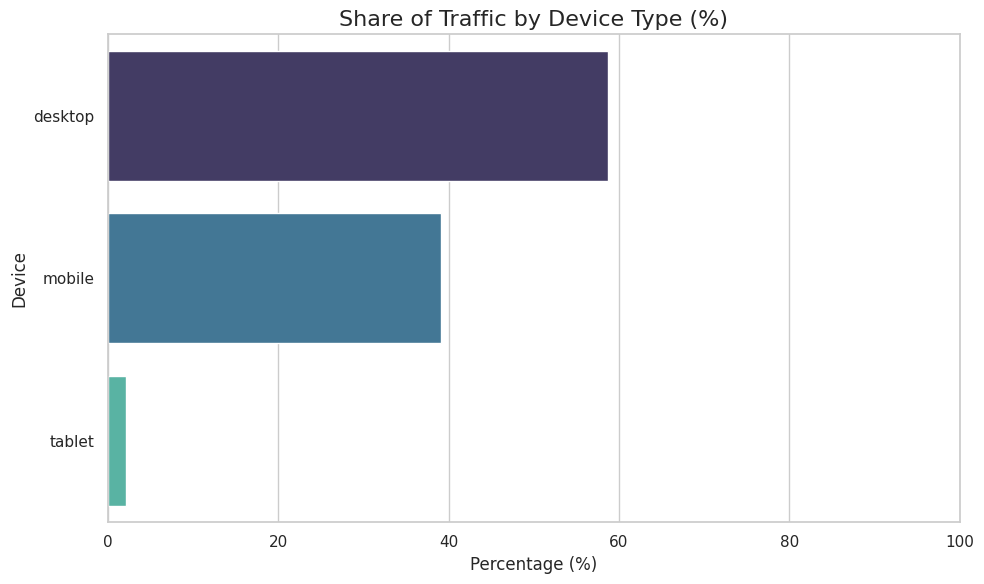

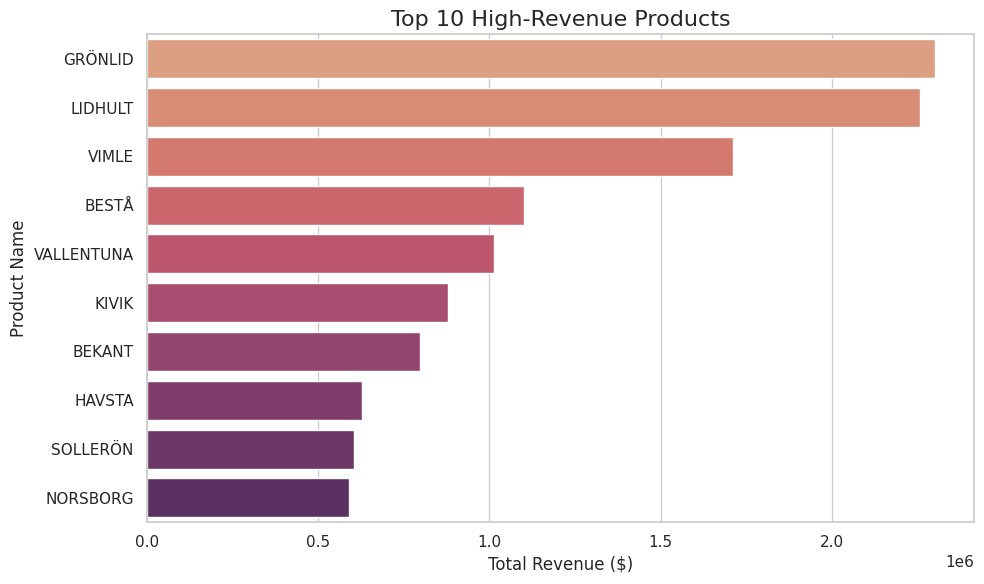

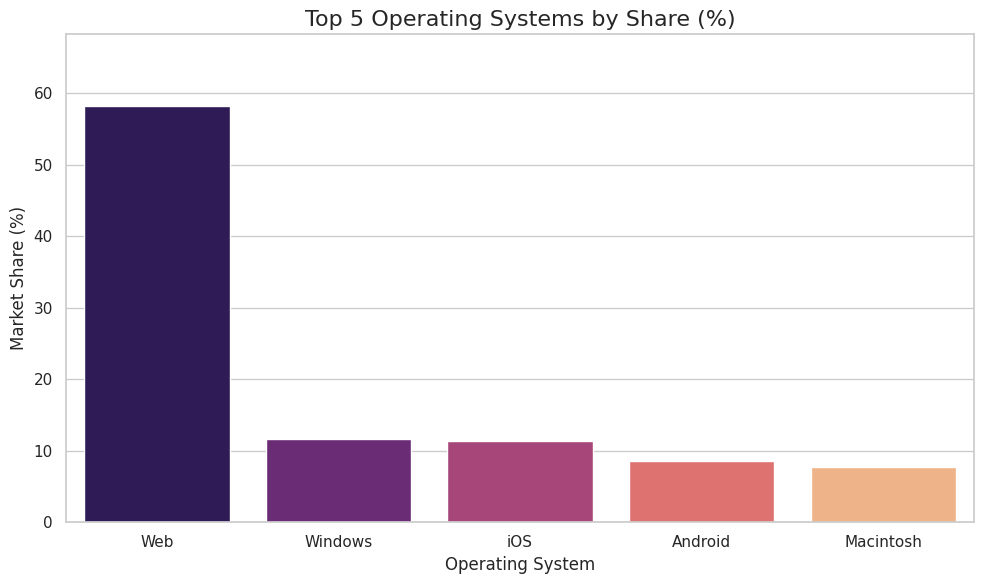

In [17]:
# =============================================================
# PHASE 4: Data Visualization & Insights
# =============================================================

# Step 1: Global Viz Setup
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Define standard plot size

# --- Chart 1: Top 10 Countries by Total Revenue ---
# Goal: Identify key revenue-generating markets.
top10_revenue_country = df.groupby('country')['price'].sum().sort_values(ascending=False).head(10).reset_index()

# Sort by descending revenue for clear analysis
sns.barplot(data=top10_revenue_country, x='price', y='country', hue='country', palette='viridis', legend=False)
plt.title('Top 10 Countries by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout() # Optimizes spacing
plt.show()


# --- Chart 2: Revenue Distribution by Product Category ---
# Goal: Visualize which categories dominate sales.
# Step 1: Prepare data
category_revenue = df.groupby('category')['price'].sum().sort_values(ascending=False).reset_index()

# Step 2: Calculate percentage share for each category
total_revenue = category_revenue['price'].sum()
category_revenue['percentage'] = (category_revenue['price'] / total_revenue * 100).round(1)

# Step 3: Create horizontal bar chart
ax = sns.barplot(data=category_revenue, x='price', y='category', hue='category', palette='pastel', legend=False)

# Add titles and axis labels
plt.title('Revenue Contribution by Product Category', fontsize=16)
plt.xlabel('Total Revenue (%, From total)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Step 4: Add percentage annotations directly to the end of each bar
for i, p in enumerate(ax.patches):
    percentage = category_revenue.iloc[i]['percentage']
    # Add text slightly to the right of the bar's end (offset points)
    ax.annotate(f'{percentage}%',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, color='black',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()


# --- Chart 3: User Registration Status Breakdown ---
# Goal: Visualize the share of traffic converting to registered accounts.
# Calculate normalized counts (percentages)
reg_counts = df['is_registered'].value_counts(normalize=True).reset_index()
reg_counts.columns = ['status', 'percentage']
reg_counts['percentage'] *= 100

# Bar plot with explicit ordering
ax = sns.barplot(data=reg_counts, x='status', y='percentage', hue='status', palette='Set2', legend=False)
plt.title('Share of Users by Registration Status (%)', fontsize=16)
plt.ylabel('Percentage of Users (%)', fontsize=12)
plt.xlabel('Status', fontsize=12)
plt.ylim(0, 100)

# Add percentage labels directly on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()


# --- Chart 4: Revenue Share: Registered vs. Guest Users ---
# Goal: Showcase the disproportionate business value of registered users.
# Calculate revenue share directly
reg_revenue_share = df.groupby('is_registered')['price'].sum().sort_values(ascending=False)

plt.pie(reg_revenue_share, labels=reg_revenue_share.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('pastel', n_colors=2))
plt.title('Total Revenue Share by Registration Status', fontsize=16)
plt.tight_layout()
plt.show()


# --- Chart 5: Top 10 Marketing Channels by Revenue ---
# Goal: Evaluate channel effectiveness and ROI for prioritization.
channel_revenue = df.groupby('channel')['price'].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=channel_revenue, x='price', y='channel', hue='channel', palette='rocket', legend=False)
plt.title('Revenue Generated by Marketing Channel', fontsize=16)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Marketing Channel', fontsize=12)
plt.tight_layout()
plt.show()


# --- Chart 6: Device Type Distribution ---
# Goal: Define technical traffic demographics (mobile vs. desktop).
device_share = df['device'].value_counts(normalize=True).reset_index()
device_share.columns = ['device', 'percentage']
device_share['percentage'] *= 100

sns.barplot(data=device_share, x='percentage', y='device', hue='device', palette='mako', legend=False)
plt.title('Share of Traffic by Device Type (%)', fontsize=16)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Device', fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


# --- Chart 7: Top 10 Products by Total Revenue ---
# Goal: Focus on the individual "heroes" generating the most profit.
top10_products = df.groupby('product_name')['price'].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top10_products, x='price', y='product_name', hue='product_name', palette='flare', legend=False)
plt.title('Top 10 High-Revenue Products', fontsize=16)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()


# --- Chart 8: Top 5 Operating Systems by Market Share ---
# Goal: Provide necessary platform data for technical development.
# Calculate normalized Top 5 only
top5_os = df['operating_system'].value_counts(normalize=True).head(5).reset_index()
top5_os.columns = ['os_name', 'percentage']
top5_os['percentage'] *= 100

sns.barplot(data=top5_os, x='os_name', y='percentage', hue='os_name', palette='magma', legend=False)
plt.title('Top 5 Operating Systems by Share (%)', fontsize=16)
plt.ylabel('Market Share (%)', fontsize=12)
plt.xlabel('Operating System', fontsize=12)
# Set Y-axis slightly higher than max for label spacing
plt.ylim(0, top5_os['percentage'].max() + 10)
plt.tight_layout()
plt.show()

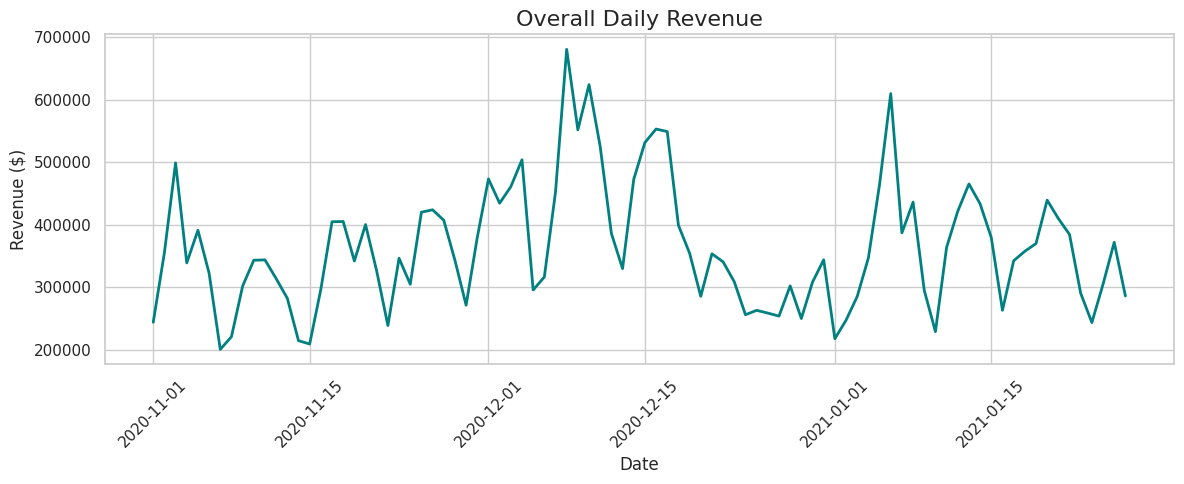

/tmp/ipykernel_703/3998679430.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_weekday = df.groupby('day_of_week')['price'].sum().reset_index()


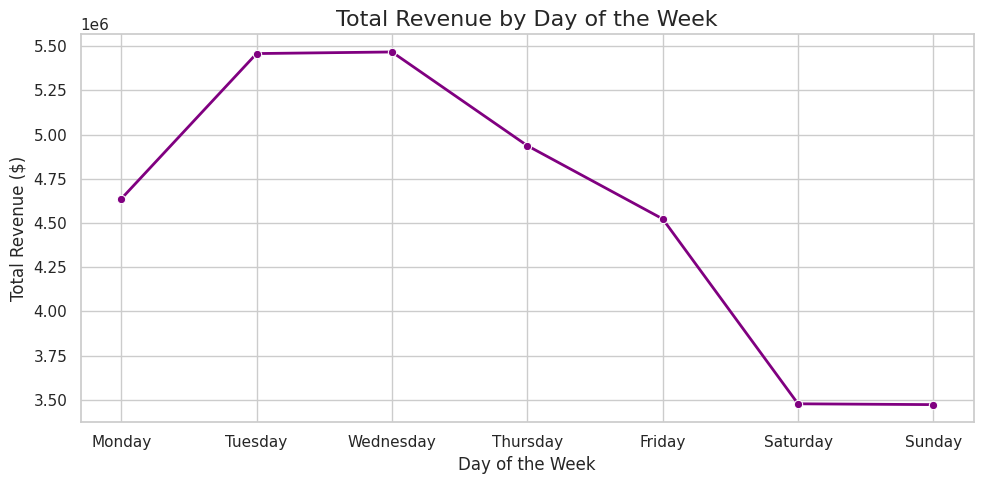

continent   Americas      Asia   Europe
date                                   
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0
...              ...       ...      ...
2021-01-23  155342.9   68543.0  62883.6
2021-01-24  116989.4   74801.2  47534.8
2021-01-25  182548.1   66215.2  55621.0
2021-01-26  215973.0   77995.2  67143.1
2021-01-27  166735.5   66783.1  48156.1

[88 rows x 3 columns]


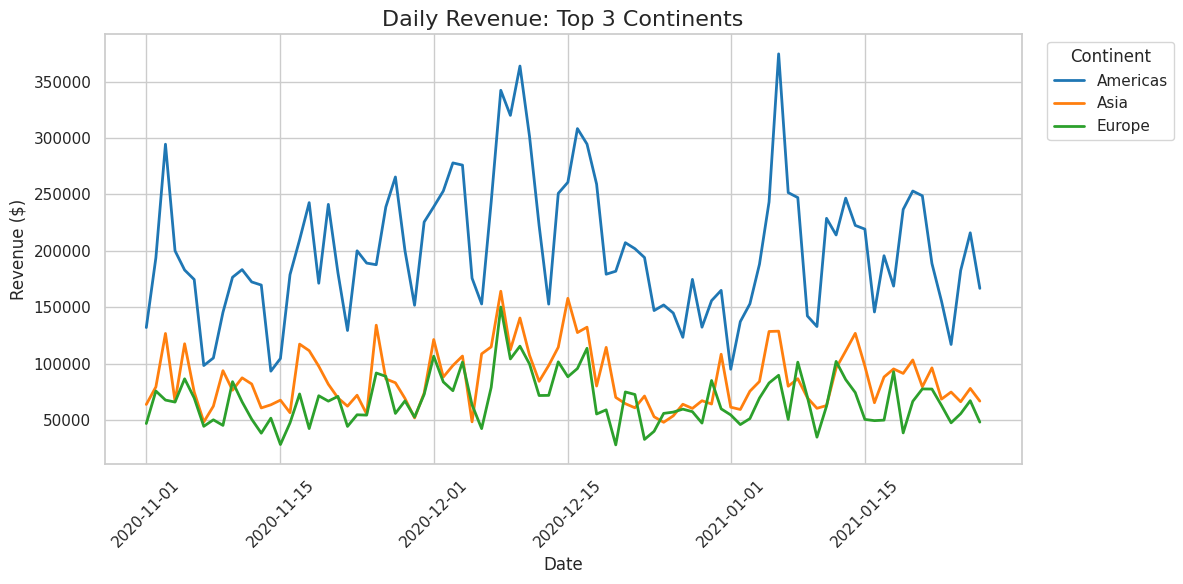

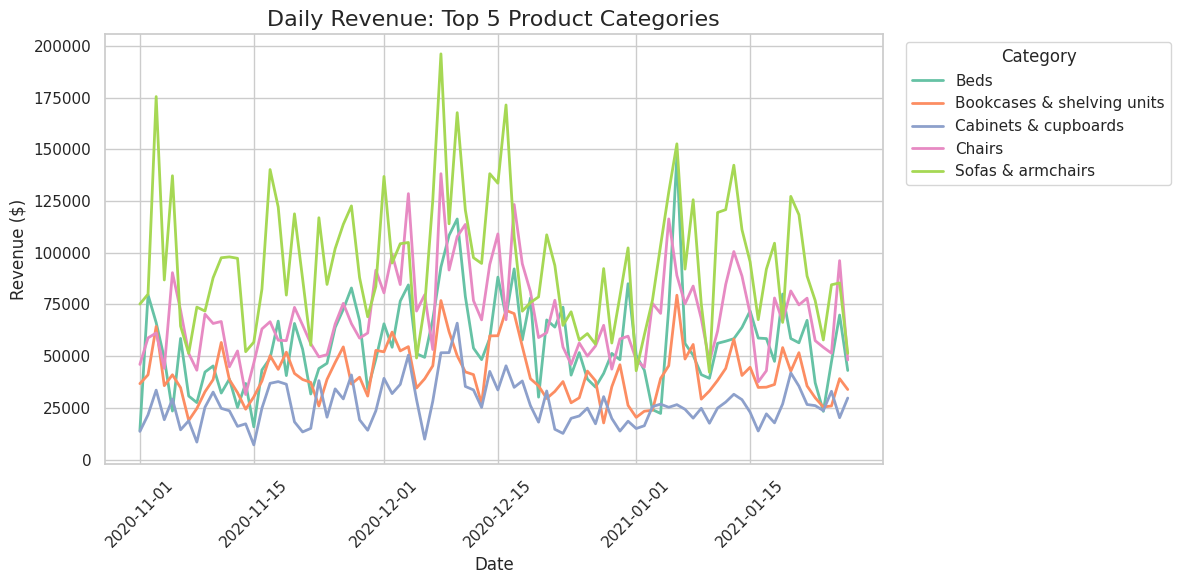

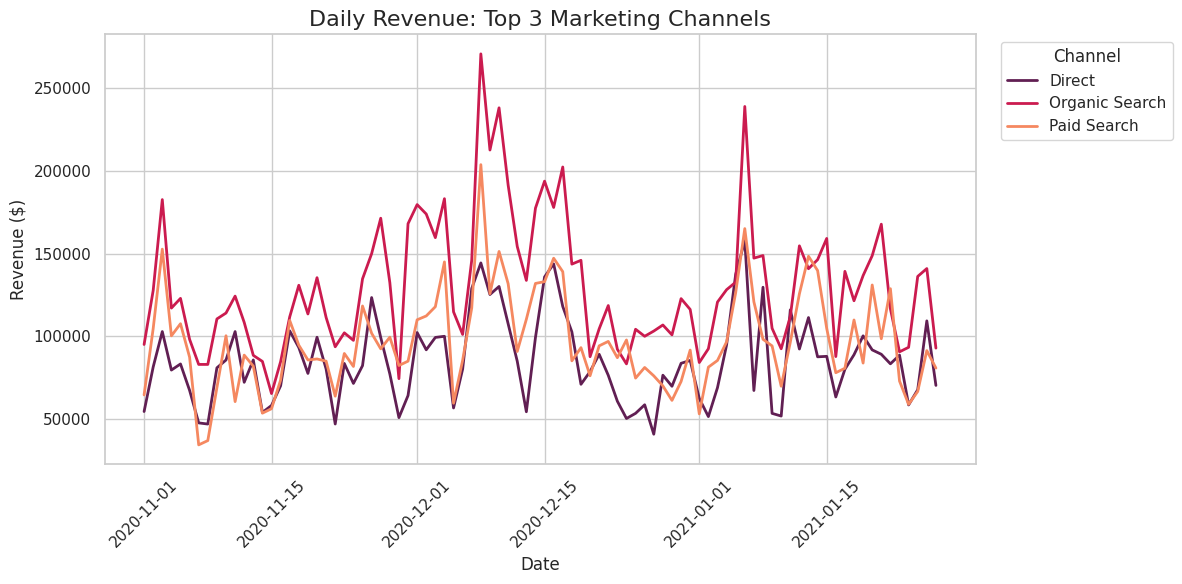

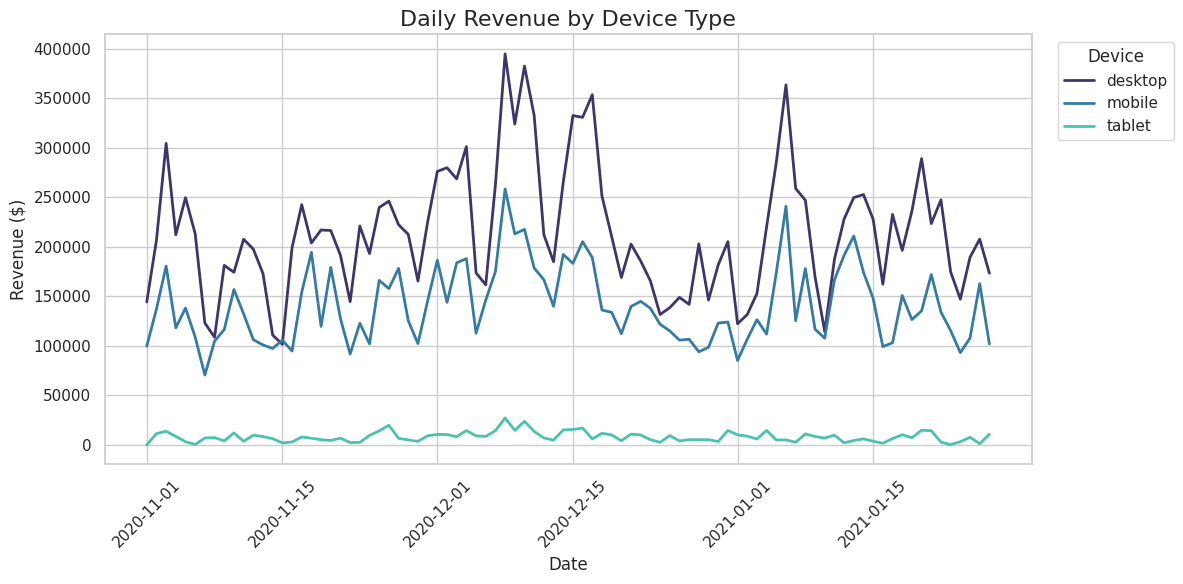

In [18]:
# =============================================================
# PHASE 5: Time Series & Trend Analysis
# =============================================================

# Ensure date column is strictly in datetime format
df['date'] = pd.to_datetime(df['date'])

# --- 1. Overall Daily Revenue Dynamics ---
plt.figure(figsize=(12, 5))
revenue_dynamics = df.groupby('date')['price'].sum().reset_index()
sns.lineplot(data=revenue_dynamics, x='date', y='price', color='teal', linewidth=2)
plt.title('Overall Daily Revenue', fontsize=16)
plt.ylabel('Revenue ($)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- 2. Revenue by Day of the Week ---
# Extract day names and set chronological order
df['day_of_week'] = df['date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

plt.figure(figsize=(10, 5))
revenue_by_weekday = df.groupby('day_of_week')['price'].sum().reset_index()
# Added marker='o' to highlight the specific data points on the line
sns.lineplot(data=revenue_by_weekday, x='day_of_week', y='price', color='purple', linewidth=2, marker='o')
plt.title('Total Revenue by Day of the Week', fontsize=16)
plt.ylabel('Total Revenue ($)')
plt.xlabel('Day of the Week')
plt.tight_layout()
plt.show()


# --- 3. Revenue Trends: Top 3 Continents ---
plt.figure(figsize=(12, 6))
# Filter for Top 3 continents
top3_continents = df.groupby('continent')['price'].sum().nlargest(3).index.tolist()
df_filtered_cont = df[df['continent'].isin(top3_continents)]

# Create pivot table with fill_value=0 to prevent broken lines
daily_cont_revenue = df_filtered_cont.pivot_table(values='price', index='date', columns='continent', aggfunc='sum', fill_value=0)
print(daily_cont_revenue)

sns.lineplot(data=daily_cont_revenue, palette='tab10', linewidth=2, dashes=False)
plt.title('Daily Revenue: Top 3 Continents', fontsize=16)
plt.ylabel('Revenue ($)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- 4. Revenue Trends: Top 5 Categories ---
plt.figure(figsize=(12, 6))
top5_categories = df.groupby('category')['price'].sum().nlargest(5).index.tolist()
df_filtered_category = df[df['category'].isin(top5_categories)]

dynamics_revenue_cat = df_filtered_category.pivot_table(values='price', index='date', columns='category', aggfunc='sum', fill_value=0)

sns.lineplot(data=dynamics_revenue_cat, palette='Set2', linewidth=2, dashes=False)
plt.title('Daily Revenue: Top 5 Product Categories', fontsize=16)
plt.ylabel('Revenue ($)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- 5. Revenue Trends: Top 3 Marketing Channels ---
plt.figure(figsize=(12, 6))
top3_channels = df.groupby('channel')['price'].sum().nlargest(3).index.tolist()
df_filtered_channel = df[df['channel'].isin(top3_channels)]

dynamics_revenue_channel = df_filtered_channel.pivot_table(values='price', index='date', columns='channel', aggfunc='sum', fill_value=0)

sns.lineplot(data=dynamics_revenue_channel, palette='rocket', linewidth=2, dashes=False)
plt.title('Daily Revenue: Top 3 Marketing Channels', fontsize=16)
plt.ylabel('Revenue ($)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Channel', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- 6. Revenue Trends by Device Type ---
plt.figure(figsize=(12, 6))
# Using groupby instead of pivot_table for variety
dynamics_revenue_device = df.groupby(['date', 'device'])['price'].sum().reset_index()

sns.lineplot(data=dynamics_revenue_device, x='date', y='price', hue='device', palette='mako', linewidth=2)
plt.title('Daily Revenue by Device Type', fontsize=16)
plt.ylabel('Revenue ($)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title='Device', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:

# Step 1: Clean the data

df_clean = df.dropna(subset=['channel', 'device'])

df_clean = df_clean[
    (~df_clean['channel'].str.lower().isin(['(not set)', 'unknown'])) &
    (~df_clean['device'].str.lower().isin(['(not set)', 'unknown']))
]

# Step 2: Create the Pivot Table
sessions_pivot = df_clean.pivot_table(
    values='ga_session_id',
    index='channel',
    columns='device',
    aggfunc='nunique',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

print("--- Session Count by Traffic Channel & Device ---")
print(sessions_pivot)

# Step 1: Identify the Top 5 Countries and Top 10 Categories by total revenue
top5_countries = df.groupby('country')['price'].sum().nlargest(5).index.tolist()
top10_categories = df.groupby('category')['price'].sum().nlargest(10).index.tolist()

# Step 2: Filter the DataFrame using BOTH conditions
df_matrix_filtered = df[
    df['country'].isin(top5_countries) &
    df['category'].isin(top10_categories)
]

# Step 3: Create the Pivot Table
sales_matrix = df_matrix_filtered.pivot_table(
    values='price',
    index='country',
    columns='category',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

print("--- Sales Matrix: Top 5 Countries x Top 10 Categories ---")
print(sales_matrix)

--- Session Count by Traffic Channel & Device ---
device          desktop  mobile  tablet  Total
channel                                       
Direct             4655    2985     160   7800
Organic Search     7011    4655     255  11921
Paid Search        5261    3574     207   9042
Social Search      1594    1065      57   2716
Undefined          1181     834      44   2059
Total             19702   13113     723  33538
--- Sales Matrix: Top 5 Countries x Top 10 Categories ---
category        Bar furniture       Beds  Bookcases & shelving units  \
country                                                                
Canada                51724.0   354772.0                    278981.9   
France                11199.0   116414.0                     73830.0   
India                 57657.0   358319.5                    364507.4   
United Kingdom        22103.0   133816.0                    113987.6   
United States        330805.0  2213058.0                   1567606.9   
Total       

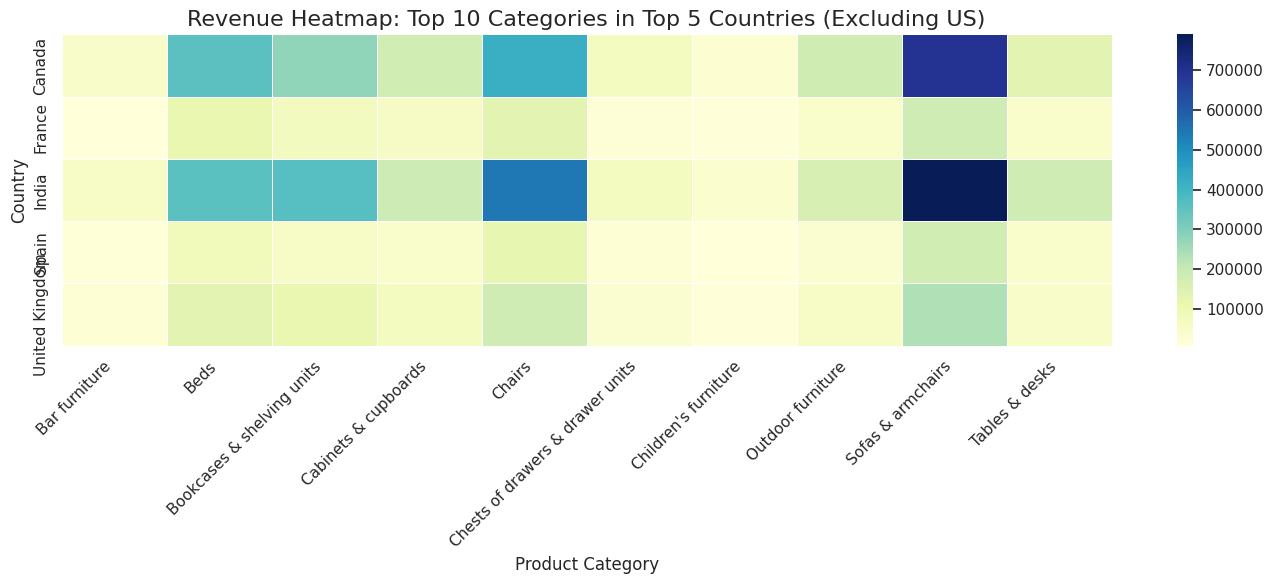

In [20]:
# --- Heatmap: Excluding Outlier (United States) ---
# Goal: Remove the dominant US market to reveal revenue variance among other top countries.

# Step 1: Filter out the outlier ('United States') from the raw data
df_no_us = df[df['country'] != 'United States']

# Step 2: Identify the NEW Top 5 Countries and Top 10 Categories (based on non-US data)
top5_countries_no_us = df_no_us.groupby('country')['price'].sum().nlargest(5).index.tolist()
top10_categories_no_us = df_no_us.groupby('category')['price'].sum().nlargest(10).index.tolist()

# Step 3: Filter the DataFrame using the new lists
df_matrix_filtered_no_us = df_no_us[
    df_no_us['country'].isin(top5_countries_no_us) &
    df_no_us['category'].isin(top10_categories_no_us)
]

# Step 4: Create the Pivot Table
sales_matrix_no_us = df_matrix_filtered_no_us.pivot_table(
    values='price',
    index='country',
    columns='category',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

# Step 5: Visualize the adjusted Matrix
plt.figure(figsize=(14, 6))

# Drop 'Total' rows/cols for the heatmap scale
heatmap_data_no_us = sales_matrix_no_us.drop('Total', axis=0).drop('Total', axis=1)

# Create the heatmap
sns.heatmap(
    heatmap_data_no_us,
    cmap='YlGnBu',
    annot=False,
    linewidths=.5,
    fmt='.0f'
)

plt.title('Revenue Heatmap: Top 10 Categories in Top 5 Countries (Excluding US)', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Spearman correlation: 0.95
P-value: 1.34633e-45

--- Daily Revenue & Sessions Matrix (First 5 Rows) ---


,date,total_revenue,unique_sessions
0,2020-11-01,244292.5,281
1,2020-11-02,355506.8,368
2,2020-11-03,498979.6,561
3,2020-11-04,339187.1,370
4,2020-11-05,391276.6,388


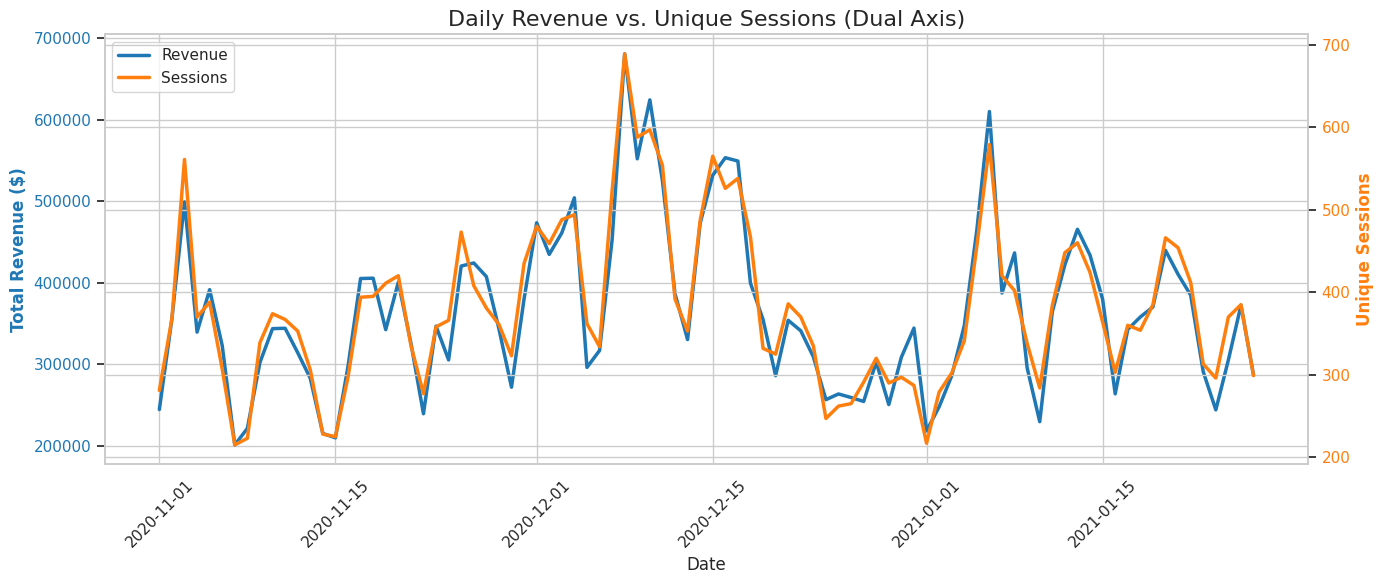


 STEP 3: CORRELATION HEATMAPS


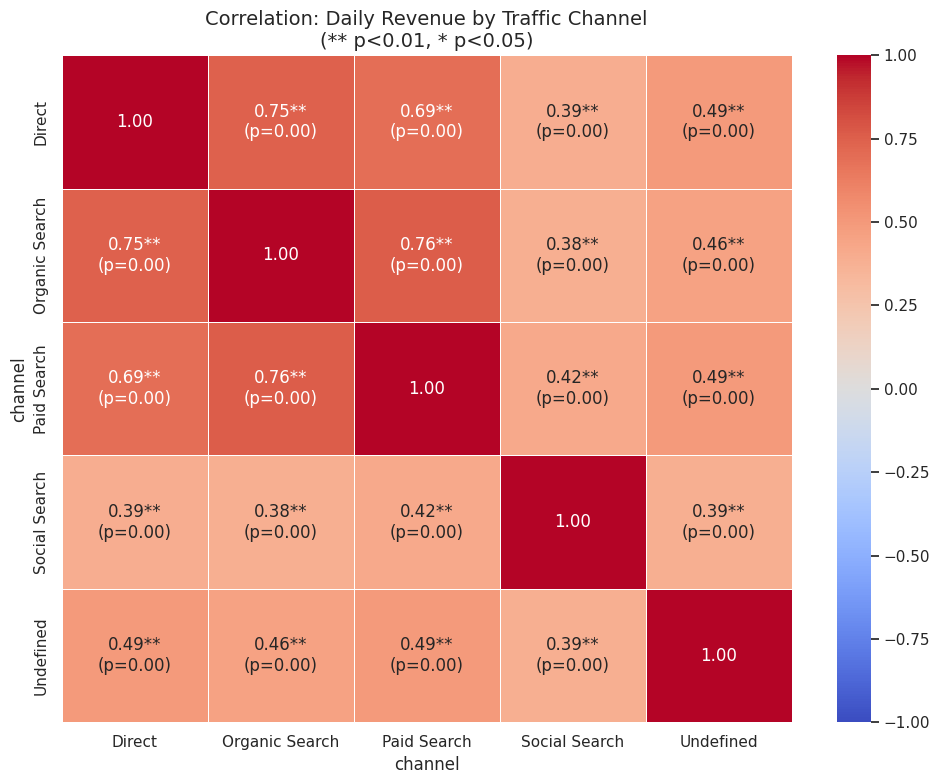

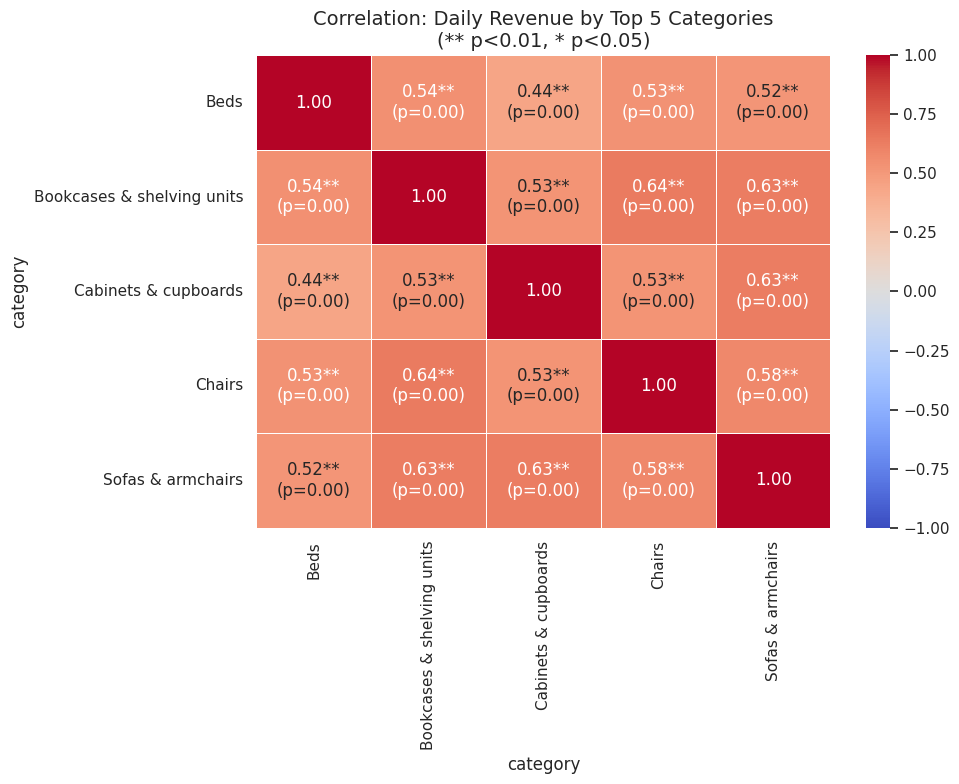

In [81]:
# 1. Aggregate daily revenue and unique sessions
dynamics_revenue_sessions = df.groupby('date').agg({
    'price': 'sum',              # Calculate total revenue
    'ga_session_id': 'nunique'   # Count UNIQUE sessions
}).reset_index()

# Rename the columns for clarity
dynamics_revenue_sessions = dynamics_revenue_sessions.rename(columns={
    'price': 'total_revenue',
    'ga_session_id': 'unique_sessions'
})

# Calculate Spearman correlation
spearman, p_value = stats.spearmanr(
    dynamics_revenue_sessions['total_revenue'],
    dynamics_revenue_sessions['unique_sessions']
)

# Output results using scientific notation for very small p-values
print(f"Spearman correlation: {spearman:.2f}")
print(f"P-value: {p_value:.5e}\n")

print("--- Daily Revenue & Sessions Matrix (First 5 Rows) ---")
display(dynamics_revenue_sessions.head())

# ---------------------------------------------------------
# Chart 1: Dual-Axis Line Chart (Revenue vs. Sessions)
# ---------------------------------------------------------
# Goal: Visualize two metrics with different scales on the same timeline.

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Total Revenue on the primary Y-axis (Left)
color_revenue = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', color=color_revenue, fontsize=12, fontweight='bold')
sns.lineplot(data=dynamics_revenue_sessions, x='date', y='total_revenue',
             color=color_revenue, ax=ax1, linewidth=2.5, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color_revenue)
ax1.tick_params(axis='x', rotation=45)

# Create a secondary Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot Unique Sessions on the secondary Y-axis (Right)
color_sessions = 'tab:orange'
ax2.set_ylabel('Unique Sessions', color=color_sessions, fontsize=12, fontweight='bold')
sns.lineplot(data=dynamics_revenue_sessions, x='date', y='unique_sessions',
             color=color_sessions, ax=ax2, linewidth=2.5, label='Sessions')
ax2.tick_params(axis='y', labelcolor=color_sessions)

# Combine legends from both axes into one box
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Remove auto-generated legend from ax2 to avoid duplicates
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

plt.title('Daily Revenue vs. Unique Sessions (Dual Axis)', fontsize=16)
fig.tight_layout() # Prevents the right Y-axis label from getting cut off
plt.show()

# ---------------------------------------------------------
# Helper Functions for Heatmap P-value Annotations
# ---------------------------------------------------------

def get_pvalues_matrix(dataframe):
    """Calculates a matrix of Spearman p-values for all columns in a dataframe."""
    p_matrix = np.zeros((dataframe.shape[1], dataframe.shape[1]))

    for i in range(dataframe.shape[1]):
        for j in range(dataframe.shape[1]):
            _, p = stats.spearmanr(dataframe.iloc[:, i], dataframe.iloc[:, j])
            p_matrix[i, j] = p

    return pd.DataFrame(p_matrix, columns=dataframe.columns, index=dataframe.columns)


def get_annot_labels(corr_matrix, pval_matrix):
    """Generates custom string labels for heatmap cells including correlation and p-value stars."""
    annot_labels = np.empty(corr_matrix.shape, dtype=object)

    for i in range(corr_matrix.shape[0]):
        for j in range(corr_matrix.shape[1]):
            c = corr_matrix.iloc[i, j]
            p = pval_matrix.iloc[i, j]

            if i == j:
                annot_labels[i, j] = f"{c:.2f}" # Diagonal (1.00 correlation with itself)
            else:
                stars = "**" if p < 0.01 else "*" if p < 0.05 else ""
                annot_labels[i, j] = f"{c:.2f}{stars}\n(p={p:.2f})"

    return annot_labels

print("\n" + "==="*15)
print(" STEP 3: CORRELATION HEATMAPS")
print("==="*15)

# ---------------------------------------------------------
# Question 1: Traffic Channels Correlation
# ---------------------------------------------------------
# Pivot daily revenue by channel
daily_channel_rev = df.pivot_table(values='price', index='date', columns='channel', aggfunc='sum', fill_value=0)

# Calculate Matrices
channel_corr = daily_channel_rev.corr(method='spearman')
channel_pvals = get_pvalues_matrix(daily_channel_rev)
channel_annot = get_annot_labels(channel_corr, channel_pvals)

# Visualize Traffic Channels Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(channel_corr, annot=channel_annot, fmt="", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation: Daily Revenue by Traffic Channel\n(** p<0.01, * p<0.05)", fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Question 2: Top 5 Categories Correlation
# ---------------------------------------------------------
# Identify Top 5 categories and filter the dataframe
top5_categories = df.groupby('category')['price'].sum().nlargest(5).index.tolist()
df_top5_cat = df[df['category'].isin(top5_categories)]

# Pivot daily revenue by category
daily_cat_rev = df_top5_cat.pivot_table(values='price', index='date', columns='category', aggfunc='sum', fill_value=0)

# Calculate Matrices
cat_corr = daily_cat_rev.corr(method='spearman')
cat_pvals = get_pvalues_matrix(daily_cat_rev)
cat_annot = get_annot_labels(cat_corr, cat_pvals)

# Visualize Categories Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cat_corr, annot=cat_annot, fmt="", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation: Daily Revenue by Top 5 Categories\n(** p<0.01, * p<0.05)", fontsize=14)
plt.tight_layout()
plt.show()

 STEP 1: DATA PREPARATION (SUM AND MEAN)


,sum_registered,sum_unregistered,mean_registered,mean_unregistered
date,,,,
2020-11-01,21547.0,222745.5,979.409091,860.021236
2020-11-02,44956.8,310550.0,1362.327273,927.014925
2020-11-03,29150.5,469829.1,677.918605,907.005985
2020-11-04,20982.2,318204.9,874.258333,919.667341
2020-11-05,25334.6,365942.0,938.318519,1013.689751



 STEP 2: TOTAL REVENUE ANALYSIS (SUM)
Normaltest (Registered Sum): p_value = 0.01093
Normaltest (Unregistered Sum): p_value = 0.00557


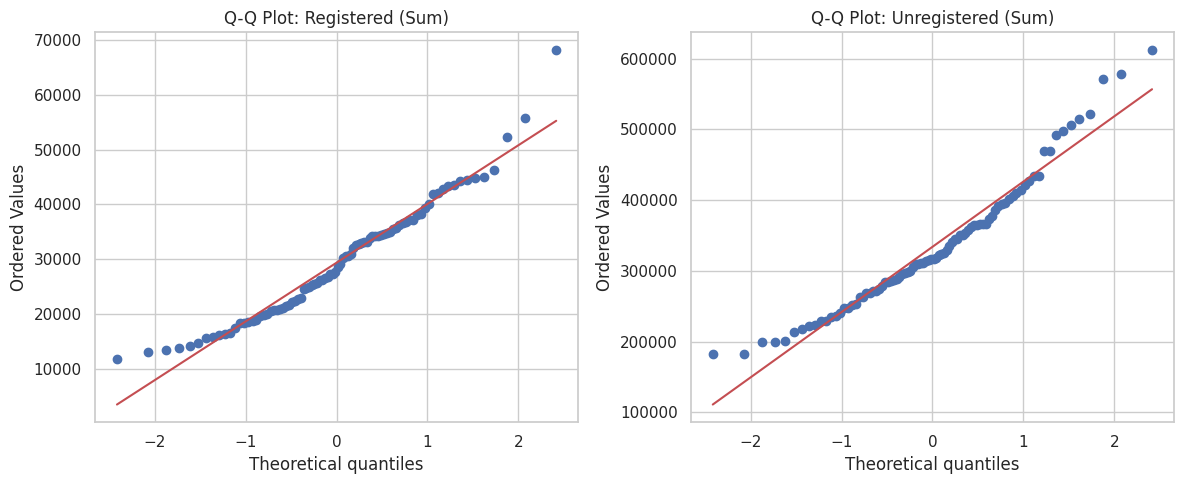


U-stat (Total Sales): 0.00
p-value (Total Sales): 0.0000000000

 STEP 3: AVERAGE ORDER VALUE ANALYSIS (MEAN)
Normaltest (Registered Mean): p_value = 0.02178
Normaltest (Unregistered Mean): p_value = 0.61663


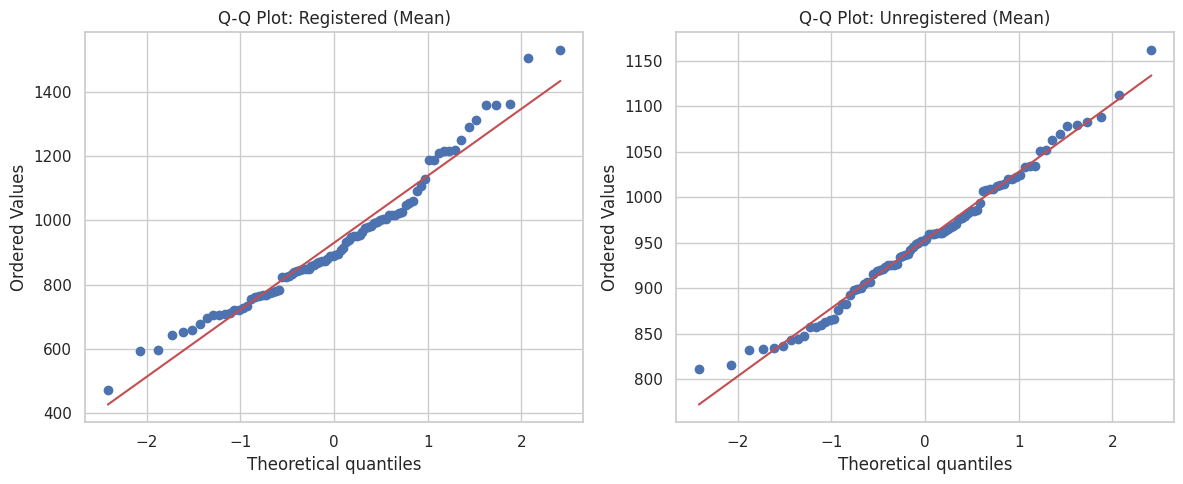


[Selected Mann-Whitney U Test]: Deviation from normality detected.
Statistic: 3155.00
p-value: 0.03401

--- Actual Median Average Order Value (AOV) ---
mean_registered      891.043750
mean_unregistered    953.185788
dtype: float64


In [84]:
print("==="*15)
print(" STEP 1: DATA PREPARATION (SUM AND MEAN)")
print("==="*15)

# Create a comprehensive pivot table
sales_comprehensive = df.pivot_table(
    values='price',
    index='date',
    columns='is_registered',
    aggfunc=['sum', 'mean'],  # Calculate both metrics (sum and mean) simultaneously
    fill_value=0
)

# 1. Flatten the MultiIndex columns
sales_comprehensive.columns = [f"{func}_{col}" for func, col in sales_comprehensive.columns]

# 2. Rename columns for better readability
sales_comprehensive = sales_comprehensive.rename(columns={
    'sum_is_registered': 'sum_registered',
    'sum_not_registered': 'sum_unregistered',
    'mean_is_registered': 'mean_registered',
    'mean_not_registered': 'mean_unregistered'
})

display(sales_comprehensive.head())


print("\n" + "==="*15)
print(" STEP 2: TOTAL REVENUE ANALYSIS (SUM)")
print("==="*15)

# Normality check (D'Agostino-Pearson)
stat_dp_reg, p_dp_reg = stats.normaltest(sales_comprehensive['sum_registered'])
print(f"Normaltest (Registered Sum): p_value = {p_dp_reg:.5f}")

stat_dp_unreg, p_dp_unreg = stats.normaltest(sales_comprehensive['sum_unregistered'])
print(f"Normaltest (Unregistered Sum): p_value = {p_dp_unreg:.5f}")

# Visualize distributions using Q-Q Plots
plt.figure(figsize=(12, 5)) # Set figure size for readability
plt.subplot(1, 2, 1)
stats.probplot(sales_comprehensive['sum_registered'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Registered (Sum)")

plt.subplot(1, 2, 2)
stats.probplot(sales_comprehensive['sum_unregistered'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Unregistered (Sum)")
plt.tight_layout()
plt.show()

# Since revenue sums typically have outliers/skewness, we use the Mann-Whitney U test
stat_mw_sum, p_mw_sum = stats.mannwhitneyu(
    x=sales_comprehensive['sum_registered'],
    y=sales_comprehensive['sum_unregistered']
)
print(f"\nU-stat (Total Sales): {stat_mw_sum:.2f}")
print(f"p-value (Total Sales): {p_mw_sum:.10f}")


print("\n" + "==="*15)
print(" STEP 3: AVERAGE ORDER VALUE ANALYSIS (MEAN)")
print("==="*15)

# Normality check
stat_dp_mean_reg, p_dp_mean_reg = stats.normaltest(sales_comprehensive['mean_registered'])
print(f"Normaltest (Registered Mean): p_value = {p_dp_mean_reg:.5f}")

stat_dp_mean_unreg, p_dp_mean_unreg = stats.normaltest(sales_comprehensive['mean_unregistered'])
print(f"Normaltest (Unregistered Mean): p_value = {p_dp_mean_unreg:.5f}")

# Visualize distributions using Q-Q Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(sales_comprehensive['mean_registered'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Registered (Mean)")

plt.subplot(1, 2, 2)
stats.probplot(sales_comprehensive['mean_unregistered'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Unregistered (Mean)")
plt.tight_layout()
plt.show()

# SMART TEST SELECTION (Automated)
alpha = 0.05
if p_dp_mean_reg >= alpha and p_dp_mean_unreg >= alpha:
    print("\n[Selected T-test]: Both distributions are normal.")
    stat_test, p_val_test = stats.ttest_ind(
        a=sales_comprehensive['mean_registered'].dropna(),
        b=sales_comprehensive['mean_unregistered'].dropna(),
        equal_var=False # Welch's t-test handles unequal variances
    )
else:
    print("\n[Selected Mann-Whitney U Test]: Deviation from normality detected.")
    stat_test, p_val_test = stats.mannwhitneyu(
        x=sales_comprehensive['mean_registered'].dropna(),
        y=sales_comprehensive['mean_unregistered'].dropna()
    )

print(f"Statistic: {stat_test:.2f}")
print(f"p-value: {p_val_test:.5f}")

print("\n--- Actual Median Average Order Value (AOV) ---")
print(sales_comprehensive[['mean_registered', 'mean_unregistered']].median())

 STEP 4: TRAFFIC CHANNELS OVERVIEW (SESSIONS)
--- Unique Sessions per Channel ---


,channel,unique_sessions
0,Organic Search,11921
1,Paid Search,9042
2,Direct,7800
3,Social Search,2716
4,Undefined,2059


/tmp/ipykernel_703/3498867442.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_session_cnt, x='channel', y='unique_sessions', palette='viridis')


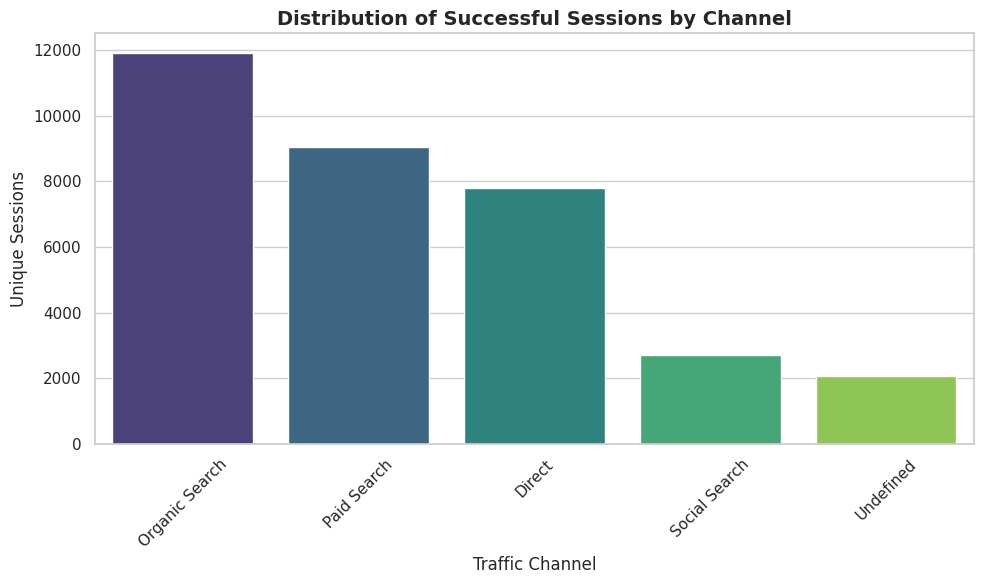


 STEP 5: STATISTICAL ANALYSIS OF CHANNELS (Full Dataset: 5 Groups)
Number of groups in test: 5
Kruskal-Wallis H-statistic: 2.78
P-value: 0.5958746073

--- STATISTICAL CONCLUSION ---
Result: NOT STATISTICALLY SIGNIFICANT (p >= 0.05).
Insight: No significant difference between channels. The average order value is statistically consistent across all sources; variations are random noise.

--- Actual Median Order Value (AOV) per Session Across All Channels ---
channel
Organic Search    450.0
Undefined         450.0
Direct            445.0
Social Search     445.0
Paid Search       430.0
Name: price, dtype: float64


In [85]:
print("==="*15)
print(" STEP 4: TRAFFIC CHANNELS OVERVIEW (SESSIONS)")
print("==="*15)

# 1. Count unique successful sessions per channel
channel_session_cnt = df.groupby('channel')['ga_session_id'].nunique().sort_values(ascending=False).reset_index()

# Rename the column for better readability in the dataframe and plot
channel_session_cnt = channel_session_cnt.rename(columns={'ga_session_id': 'unique_sessions'})

print("--- Unique Sessions per Channel ---")
display(channel_session_cnt)

# Visualize the distribution of sessions
plt.figure(figsize=(10, 6))
sns.barplot(data=channel_session_cnt, x='channel', y='unique_sessions', palette='viridis')

# Add professional formatting to the plot
plt.title('Distribution of Successful Sessions by Channel', fontsize=14, fontweight='bold')
plt.ylabel('Unique Sessions', fontsize=12)
plt.xlabel('Traffic Channel', fontsize=12)
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.tight_layout()
plt.show()


print("\n" + "==="*15)
print(" STEP 5: STATISTICAL ANALYSIS OF CHANNELS (Full Dataset: 5 Groups)")
print("==="*15)

# 1. Calculate total revenue for EACH unique session
session_revenue = df.groupby(['ga_session_id', 'channel'])['price'].sum().reset_index()

# 2. Extract arrays of revenue for all 5 channels
organic = session_revenue[session_revenue['channel'] == 'Organic Search']['price'].dropna()
paid = session_revenue[session_revenue['channel'] == 'Paid Search']['price'].dropna()
direct = session_revenue[session_revenue['channel'] == 'Direct']['price'].dropna()
social = session_revenue[session_revenue['channel'] == 'Social Search']['price'].dropna()
undefined = session_revenue[session_revenue['channel'] == 'Undefined']['price'].dropna()

# 3. Run Kruskal-Wallis H-test
stat_kw, p_val_kw = stats.kruskal(organic, paid, direct, social, undefined)

print(f"Number of groups in test: 5")
print(f"Kruskal-Wallis H-statistic: {stat_kw:.2f}")
print(f"P-value: {p_val_kw:.10f}\n")

# 4. Automated Business Conclusion
alpha = 0.05
print("--- STATISTICAL CONCLUSION ---")
if p_val_kw < alpha:
    print(f"Result: STATISTICALLY SIGNIFICANT (p < {alpha}).")
    print("Insight: User purchasing power differs significantly depending on the acquisition channel. At least one channel brings an audience with a different average order value.")
else:
    print(f"Result: NOT STATISTICALLY SIGNIFICANT (p >= {alpha}).")
    print("Insight: No significant difference between channels. The average order value is statistically consistent across all sources; variations are random noise.")

# 5. Display actual medians for business context
print("\n--- Actual Median Order Value (AOV) per Session Across All Channels ---")
medians = session_revenue.groupby('channel')['price'].median().sort_values(ascending=False)
print(medians)

In [87]:
print("==="*15)
print(" STATISTICAL ANALYSIS OF PROPORTIONS: Organic Traffic (Europe vs. Americas)")
print("==="*15)

# STEP 1: Data Preparation
# 1.1. Create a boolean flag column: True (if Organic), False (if other channels)
df['is_organic'] = df['channel'] == 'Organic Search'

# 1.2. Filter the dataset to keep only the two target regions
df_geo = df[df['continent'].isin(['Europe', 'Americas'])]

# 1.3. Create a Contingency Table
# This is the required input format for the Chi-Square test
contingency_table = pd.crosstab(df_geo['continent'], df_geo['is_organic'])

print("--- Contingency Table (Raw Frequencies for the Test) ---")
# Rename columns for a cleaner output display
contingency_table_display = contingency_table.rename(columns={False: 'Other Channels', True: 'Organic'})
display(contingency_table_display)

# Additionally, calculate the actual proportions (percentages) for business context
print("\n--- Actual Share of Organic Traffic ---")
contingency_pct = pd.crosstab(df_geo['continent'], df_geo['is_organic'], normalize='index') * 100
display(contingency_pct.rename(columns={False: 'Other Channels (%)', True: 'Organic (%)'}).round(2))


# STEP 2: Run the Chi-Square Test
# Note: The test requires raw absolute frequencies (contingency_table) as input, not percentages!
stat_chi2, p_val_chi2, dof, expected_freq = stats.chi2_contingency(contingency_table)

print("\n" + "==="*15)
print(" CHI-SQUARE TEST RESULTS")
print("==="*15)
print(f"Chi-Square Statistic: {stat_chi2:.2f}")
print(f"P-value: {p_val_chi2:.10f}")

# STEP 3: Automated Business Conclusion
alpha = 0.05
if p_val_chi2 < alpha:
    print("\nResult: STATISTICALLY SIGNIFICANT difference (Reject the null hypothesis).")
    print("Business Insight: The share of organic traffic differs significantly between Europe and the Americas. One of the regions has a statistically stronger SEO acquisition rate.")
else:
    print("\nResult: NOT STATISTICALLY SIGNIFICANT (Fail to reject the null hypothesis).")
    print("Business Insight: Users in Europe and the Americas arrive via organic search at the same relative frequency. Any visible difference in percentages is likely due to random variance.")

 STATISTICAL ANALYSIS OF PROPORTIONS: Organic Traffic (Europe vs. Americas)
--- Contingency Table (Raw Frequencies for the Test) ---


is_organic,Other Channels,Organic
continent,,
Americas,12017,6536
Europe,4023,2238



--- Actual Share of Organic Traffic ---


is_organic,Other Channels (%),Organic (%)
continent,,
Americas,64.77,35.23
Europe,64.25,35.75



 CHI-SQUARE TEST RESULTS
Chi-Square Statistic: 0.52
P-value: 0.4693235740

Result: NOT STATISTICALLY SIGNIFICANT (Fail to reject the null hypothesis).
Business Insight: Users in Europe and the Americas arrive via organic search at the same relative frequency. Any visible difference in percentages is likely due to random variance.
